# Basic usage — 2D image analyzers (BeamAnalyzer & friends)

Two workflows for getting a configured ImageAnalyzer:

- **Mode 2 — config-driven.** Load a unified diagnostic YAML from the configs tree, optionally mutate, build the analyzer. Same code path the task queue uses, so what works here works in production.
- **Mode 1 — direct construction.** Build a `CameraConfig` in Python, hand it to the analyzer class. No YAML in the loop. Good for exploration and one-off scripts.

This notebook walks through Mode 2 first (the recommended path), then Mode 1, then a specialized analyzer (`MagSpecManualCalibAnalyzer`).

## Setup

Set the configs base directory and silence the chatty library loggers. `image_analysis_config.set_base_dir` tells the loader where to find YAMLs by name — it usually picks up the value from your `geecs_python_api/config.ini`, but we set it explicitly here for clarity.

In [1]:
import logging

from geecs_data_utils.config_roots import image_analysis_config
from geecs_data_utils.scan_data import ScanData, ScanPaths

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)
logging.getLogger("image_analysis").setLevel(logging.WARNING)
logging.getLogger("geecs_data_utils").setLevel(logging.WARNING)

image_analysis_config.set_base_dir(ScanPaths.paths_config.image_analysis_configs_path)

PosixPath('/Users/samuelbarber/Desktop/Code/Github_repos/GEECS-Plugins-Configs-loader-api-refactor/scan_analysis_configs/analyzers')

Pick a scan to test against. Substitute your own date/scan/experiment.

In [2]:
sd = ScanData.from_date(
    year=2025, month=9, day=24, number=13, experiment="Thomson", append_paths=True
)

---
## Mode 2 — config-driven

The recommended workflow. Two functions do everything:

- `load_diagnostic(name)` finds a unified YAML in the configs tree, validates it, returns a `DiagnosticAnalysisConfig`.
- `create_image_analyzer(diag)` builds the live `ImageAnalyzer` instance (e.g., `BeamAnalyzer`) from that config.

Replace `dev_name` below with any diagnostic in your `analyzers/<namespace>/` tree.

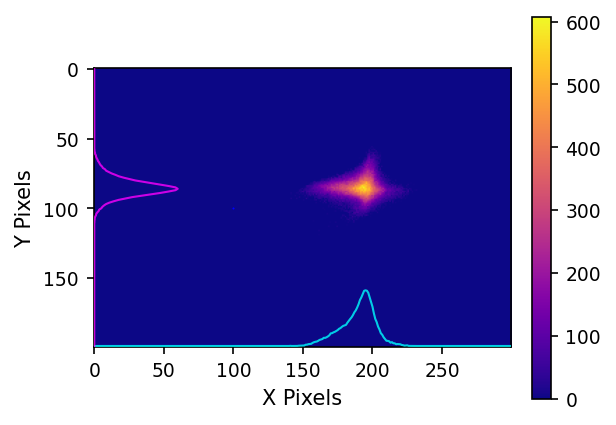

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='X Pixels', ylabel='Y Pixels'>)

In [3]:
from image_analysis.config import create_image_analyzer, load_diagnostic

dev_name = "HTT-C-ASSERTHighR"

diag = load_diagnostic(dev_name)
analyzer = create_image_analyzer(diag)

file_path = sd.data_frame[f"{dev_name}_expected_path"][10]
result = analyzer.analyze_image_file(file_path)
analyzer.visualize(result)

### Inspecting the loaded config

`diag` is a Pydantic model. The `image:` block (the camera-specific processing config) is at `diag.image`; runtime scan settings (priority, gdoc slot, ...) are at `diag.scan` as a raw dict.

In [4]:
import yaml

print(yaml.dump(diag.model_dump(), sort_keys=False, default_flow_style=False))

name: HTT-C-ASSERTHighR
image_analyzer:
  class_path: image_analysis.analyzers.beam_analyzer.BeamAnalyzer
  kwargs: {}
image:
  type: camera
  name: HTT-C-ASSERTHighR
  description: high resolution for electron beam profile analysis
  bit_depth: 16
  roi:
    x_min: 675
    x_max: 975
    y_min: 100
    y_max: 300
  background:
    enabled: true
    method: !!python/object/apply:image_analysis.config.array2d_processing.BackgroundMethod
    - constant
    file_path: null
    constant_level: 100.0
    additional_constant: 0.0
  crosshair_masking:
    enabled: false
    crosshairs: []
    mask_value: 0.0
  circular_mask: null
  vignette: null
  thresholding:
    enabled: true
    method: !!python/object/apply:image_analysis.config.array2d_processing.ThresholdMethod
    - constant
    value: 0.0
    mode: !!python/object/apply:image_analysis.config.array2d_processing.ThresholdMode
    - to_zero
    invert: false
  filtering:
    gaussian_sigma: null
    median_kernel_size: null
  normaliza

### Tweaking before re-analyzing

Two equivalent patterns. Pick whichever reads better in context.

**(a) Mutate the loaded config, rebuild the analyzer.** Honest about what's happening — the new analyzer is constructed from the modified config.

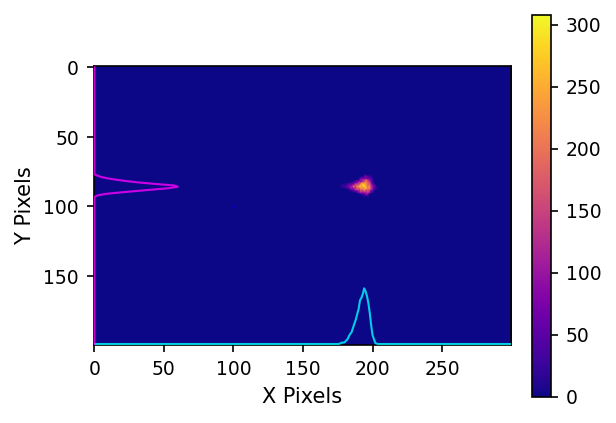

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='X Pixels', ylabel='Y Pixels'>)

In [5]:
diag.image.background.method = "constant"
diag.image.background.constant_level = 400

analyzer = create_image_analyzer(diag)
result = analyzer.analyze_image_file(file_path)
analyzer.visualize(result)

**(b) Mutate the live analyzer's stored config.** Works because the analyzer's `camera_config` is the same Pydantic model — mutations to it are picked up on the next `analyze_image_file` call. No rebuild needed.

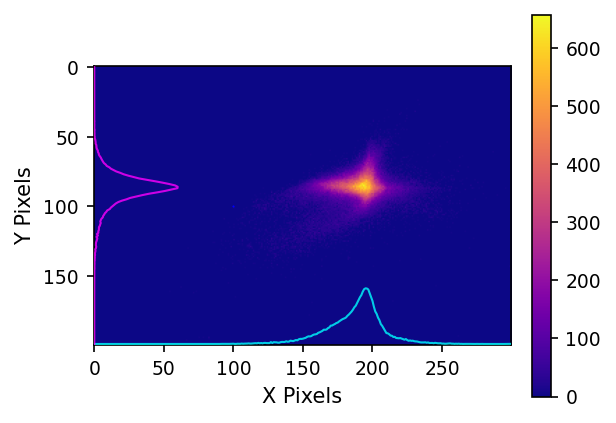

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='X Pixels', ylabel='Y Pixels'>)

In [6]:
analyzer.camera_config.background.constant_level = 50  # back to something modest

result = analyzer.analyze_image_file(file_path)
analyzer.visualize(result)

### Reload the original config

To reset, just `load_diagnostic` again and rebuild — that drops any mutations and gives you back the on-disk config.

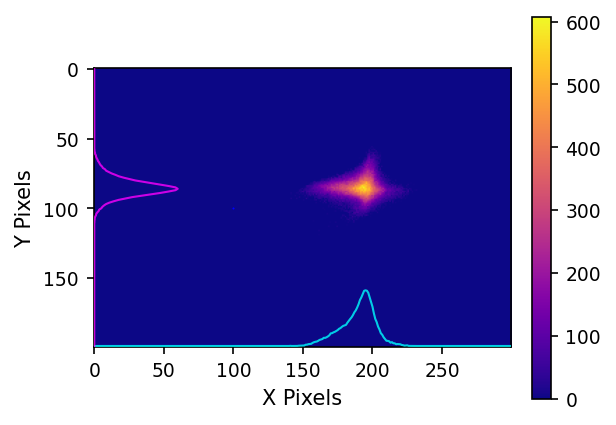

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='X Pixels', ylabel='Y Pixels'>)

In [7]:
diag = load_diagnostic(dev_name)
analyzer = create_image_analyzer(diag)

result = analyzer.analyze_image_file(file_path)
analyzer.visualize(result)

### Static circular mask example

Adjust any processing config section on the live analyzer the same way.

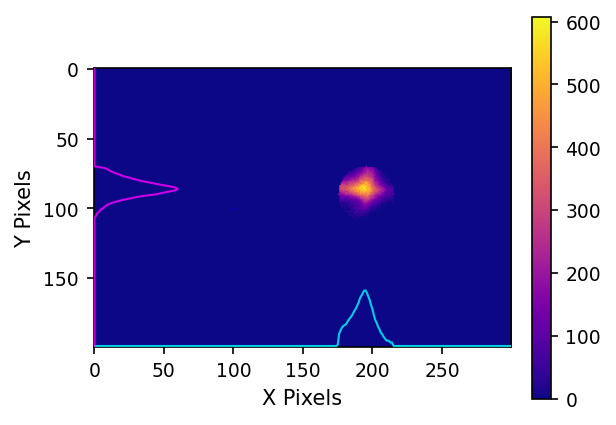

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='X Pixels', ylabel='Y Pixels'>)

In [8]:
from image_analysis.config import CircularMaskConfig

analyzer.camera_config.circular_mask = CircularMaskConfig(
    center=(195, 90),
    radius=20,
    enabled=True,
)

result = analyzer.analyze_image_file(file_path)
analyzer.visualize(result)

### Transforms (applied after ROI and masking)

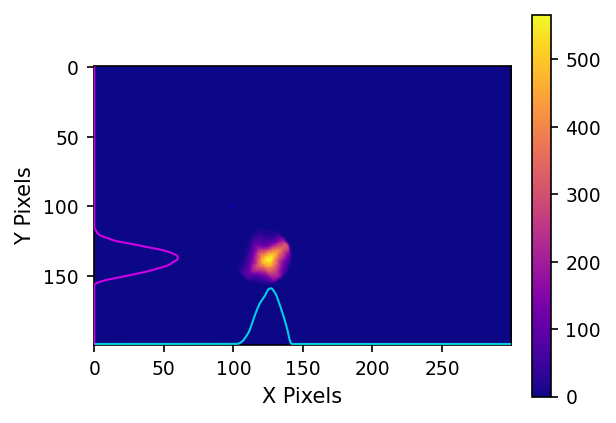

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='X Pixels', ylabel='Y Pixels'>)

In [9]:
from image_analysis.config import TransformConfig

analyzer.camera_config.transforms = TransformConfig(
    flip_horizontal=True,
    flip_vertical=True,
    rotation_angle=40,
)

result = analyzer.analyze_image_file(file_path)
analyzer.visualize(result)

---
## Mode 1 — direct construction (no YAML)

When you want to explore parameter space without touching disk configs, build a `CameraConfig` in Python and hand it to `BeamAnalyzer` directly. You own the object, mutate freely.

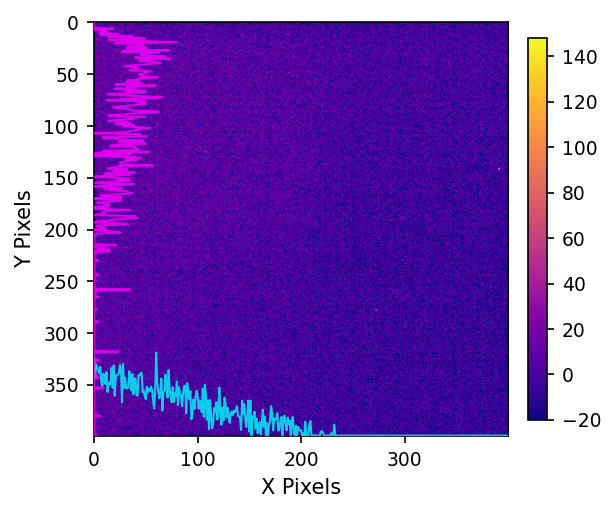

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='X Pixels', ylabel='Y Pixels'>)

In [10]:
from image_analysis.analyzers.beam_analyzer import BeamAnalyzer
from image_analysis.config import BackgroundConfig, CameraConfig, ROIConfig

cfg = CameraConfig(
    name="MyExploration",
    bit_depth=16,
    roi=ROIConfig(x_min=0, x_max=400, y_min=0, y_max=400),
    background=BackgroundConfig(method="constant", constant_level=20),
)

analyzer = BeamAnalyzer(camera_config=cfg)

result = analyzer.analyze_image_file(file_path)
analyzer.visualize(result)

---
## Specialized analyzers

The same patterns work for any analyzer class. Specialized analyzers (`MagSpecManualCalibAnalyzer`, `GrenouilleAnalyzer`, `ICT1DAnalyzer`, ...) consume the same `CameraConfig` / `Line1DConfig` shapes — they just add domain-specific logic on top.

In [ ]:
sd_mag = ScanData.from_date(
    year=2025, month=8, day=19, number=2, experiment="Undulator", append_paths=False
)

dev_name_mag = "UC_HiResMagCam"

# Mode 2: load the diagnostic, build the analyzer
diag_mag = load_diagnostic(dev_name_mag)
analyzer_mag = create_image_analyzer(diag_mag)

tag = sd_mag.paths.get_tag()
file_path_mag = sd_mag.paths.get_device_shot_path(
    device_name=dev_name_mag, shot_number=10, tag=tag
)
result_mag = analyzer_mag.analyze_image_file(image_filepath=file_path_mag)
analyzer_mag.visualize(result_mag)

---
## Reference

**Imports cheat sheet**

```python
# Mode 2 entry points
from image_analysis.config import load_diagnostic, create_image_analyzer

# Mode 1 building blocks
from image_analysis.config import (
    CameraConfig,
    ROIConfig, BackgroundConfig, CrosshairMaskingConfig,
    CircularMaskConfig, VignetteConfig, ThresholdingConfig,
    FilteringConfig, NormalizationConfig, TransformConfig,
)
from image_analysis.analyzers.beam_analyzer import BeamAnalyzer
from image_analysis.analyzers.standard_analyzer import StandardAnalyzer

# Specialized analyzers
from image_analysis.analyzers.grenouille_analyzer import GrenouilleAnalyzer
from image_analysis.analyzers.magspec_manual_calib_analyzer import (
    MagSpecManualCalibAnalyzer,
)
```

**When to use which mode**

- Mode 2 when the configuration lives on disk and you want production parity.
- Mode 1 when you're exploring parameter space, prototyping, or running a one-off without committing a YAML.
- Both modes go through the same `create_image_analyzer` factory — the only difference is whether you constructed the config in Python or loaded it from disk.